In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.cluster import DBSCAN
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import NearestNeighbors

# Configurações de visualização
%matplotlib inline
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None) # Mostrar todas as colunas

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [8]:
# Recarregando os dados para garantir a integridade
data_path = '../../data/raw/UNSW-NB15'

df_train = pd.read_csv(os.path.join(data_path, 'UNSW_NB15_training-set.csv'))
df_test = pd.read_csv(os.path.join(data_path, 'UNSW_NB15_testing-set.csv'))

df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)
df_train['service'] = df_train['service'].replace('-', 'unknown')
df_test['service'] = df_test['service'].replace('-', 'unknown')

print("\nDados carregados.")

# Filtrar o conjunto de treino para conter APENAS o tráfego normal
df_train_normal = df_train[df_train['label'] == 0]
X_train_normal = df_train_normal.drop(['attack_cat', 'label'], axis=1)

# Preparar o conjunto de teste completo para a aplicação do DBSCAN
X_test = df_test.drop(['attack_cat', 'label'], axis=1)
y_test = df_test['label'] # Rótulos verdadeiros para avaliação final

# Definir o pré-processador
numeric_features = X_train_normal.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train_normal.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Ajustar (fit) o pré-processador nos dados de treino normais
print("Ajustando o pré-processador nos dados normais...")
preprocessor.fit(X_train_normal)

# Transformar o conjunto de teste
print("Transformando o conjunto de teste...")
X_test_processed = preprocessor.transform(X_test)

print("Dados de teste pré-processados e prontos.")


Dados carregados.
Ajustando o pré-processador nos dados normais...
Transformando o conjunto de teste...
Dados de teste pré-processados e prontos.


Criando uma subamostra de 50% dos dados de teste...
Tamanho da amostra para análise: 41166 pontos.


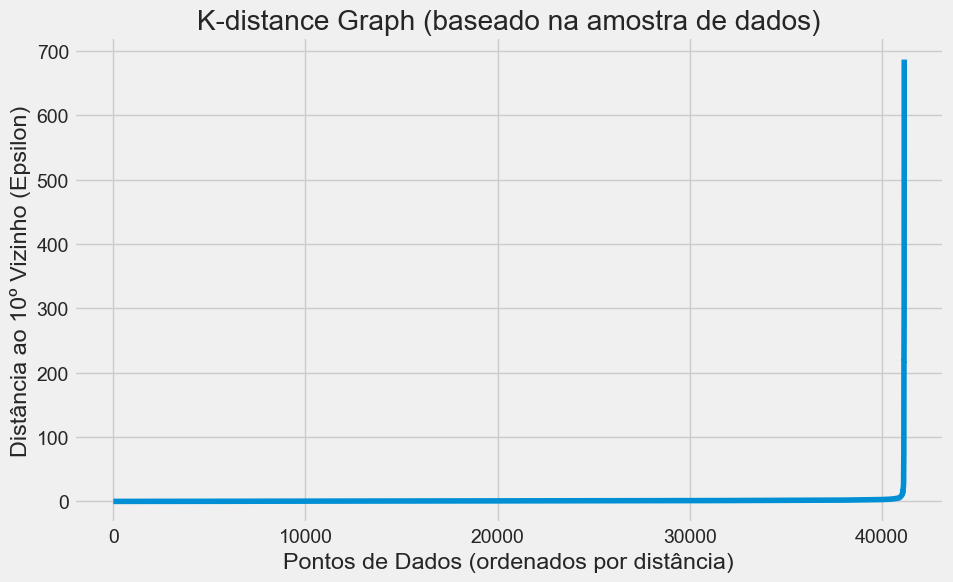

Valor de 'eps' escolhido a partir do gráfico: 8.5


In [11]:
# Vamos trabalhar com uma amostra de 25% do conjunto de teste para controlar o uso de memória
sample_fraction = 0.5
print(f"Criando uma subamostra de {sample_fraction*100:.0f}% dos dados de teste...")

# Criar um DataFrame temporário para facilitar a amostragem estratificada
df_test_processed = pd.DataFrame(X_test_processed)
df_test_processed['label'] = y_test.values

# Usar train_test_split para criar uma amostra estratificada
df_test_sample, _ = train_test_split(df_test_processed, train_size=sample_fraction, stratify=df_test_processed['label'], random_state=42)

# Separar X e y da amostra
X_test_sample = df_test_sample.drop('label', axis=1).values
y_test_sample = df_test_sample['label'].values

print(f"Tamanho da amostra para análise: {len(X_test_sample)} pontos.")

# Calcular o k-distance plot na amostra
min_samples_val = 10
neighbors = NearestNeighbors(n_neighbors=min_samples_val)
neighbors_fit = neighbors.fit(X_test_sample)
distances, indices = neighbors_fit.kneighbors(X_test_sample)

distances = np.sort(distances[:, min_samples_val-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-distance Graph (baseado na amostra de dados)')
plt.xlabel('Pontos de Dados (ordenados por distância)')
plt.ylabel(f'Distância ao {min_samples_val}º Vizinho (Epsilon)')
plt.grid(True)
plt.show()

# Com base no gráfico, escolha o valor do "cotovelo"
eps_val = 8.5 # O valor pode mudar um pouco com a amostragem, ajuste se necessário
print(f"Valor de 'eps' escolhido a partir do gráfico: {eps_val}")

Executando o DBSCAN na amostra de 41166 pontos...

Número de clusters encontrados: 3
Número de pontos de ruído (anomalias): 106

--- Relatório de Classificação Binária (DBSCAN na Amostra) ---
              precision    recall  f1-score   support

  Normal (0)       0.45      1.00      0.62     18500
  Ataque (1)       0.61      0.00      0.01     22666

    accuracy                           0.45     41166
   macro avg       0.53      0.50      0.31     41166
weighted avg       0.54      0.45      0.28     41166



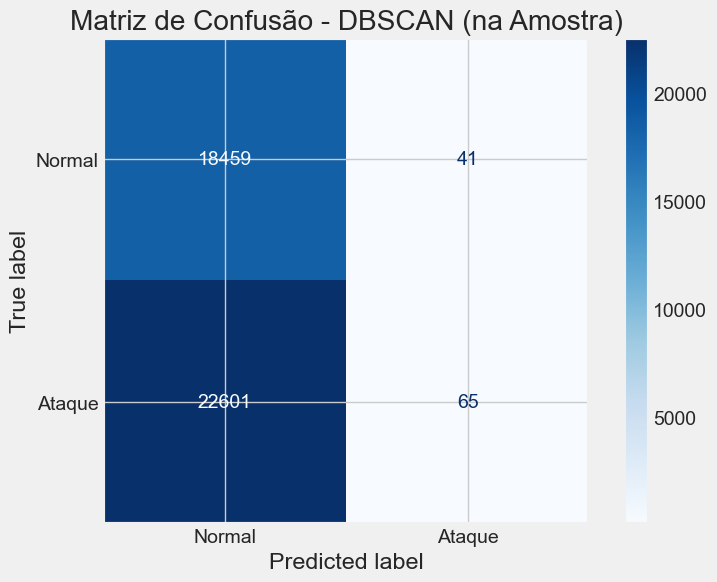

In [12]:
# Instanciar e executar o DBSCAN na subamostra de dados processados
dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val, n_jobs=-1)

print(f"Executando o DBSCAN na amostra de {len(X_test_sample)} pontos...")
y_pred_dbscan_sample = dbscan.fit_predict(X_test_sample)

# Analisar os resultados da clusterização
n_clusters = len(set(y_pred_dbscan_sample)) - (1 if -1 in y_pred_dbscan_sample else 0)
n_noise = np.sum(y_pred_dbscan_sample == -1)
print(f"\nNúmero de clusters encontrados: {n_clusters}")
print(f"Número de pontos de ruído (anomalias): {n_noise}")

# Mapear os resultados para avaliação
y_pred_mapped_sample = np.where(y_pred_dbscan_sample == -1, 1, 0)

# Avaliar os resultados usando os rótulos verdadeiros da amostra (y_test_sample)
print("\n--- Relatório de Classificação Binária (DBSCAN na Amostra) ---")
print(classification_report(y_test_sample, y_pred_mapped_sample, target_names=['Normal (0)', 'Ataque (1)']))

cm = confusion_matrix(y_test_sample, y_pred_mapped_sample)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Ataque'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusão - DBSCAN (na Amostra)')
plt.show()
